# Post EDA - Further Data Cleaning

This notebook contains the cleaning steps and updated top-20 correlation analysis moved from the post-EDA workflow.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

new_df = pd.read_csv("MSE446_cleaned_dataset.csv")

## Analysis of EDA & Further Data Cleaning

Based on the results of our EDA, we will finalize our dataset before we begin modelling.

In [2]:
# Remove all columns that start with 'ttm_' or 'l90d_'
cols_to_drop = [col for col in new_df.columns if col.startswith("ttm_") or col.startswith("l90d_")]
new_df = new_df.drop(columns=cols_to_drop)

print("Dropped columns:")
print(cols_to_drop)

Dropped columns:
['ttm_revenue', 'ttm_revenue_native', 'ttm_avg_rate', 'ttm_avg_rate_native', 'ttm_occupancy', 'ttm_adjusted_occupancy', 'ttm_revpar', 'ttm_revpar_native', 'ttm_adjusted_revpar', 'ttm_adjusted_revpar_native', 'ttm_reserved_days', 'ttm_blocked_days', 'ttm_available_days', 'ttm_total_days', 'l90d_revenue', 'l90d_revenue_native', 'l90d_avg_rate', 'l90d_avg_rate_native', 'l90d_occupancy', 'l90d_adjusted_occupancy', 'l90d_revpar', 'l90d_revpar_native', 'l90d_adjusted_revpar', 'l90d_adjusted_revpar_native', 'l90d_reserved_days', 'l90d_blocked_days', 'l90d_available_days', 'l90d_total_days']


In [3]:
# Remove rows where beds = 8
new_df = new_df[new_df["beds"] != 8]

print("New shape after removing beds=8:")
print(new_df.shape)
print(new_df["beds"].value_counts())

New shape after removing beds=8:
(3225, 96)
beds
1    1876
2     759
3     282
4     187
5      66
0      44
6      11
Name: count, dtype: int64


Top 20 remaining features by |correlation| with rate_avg:
['bedrooms', 'guests', 'baths', 'beds', 'revenue', 'listing_type_Entire home', 'cleaning_fee', 'room_type_private_room', 'photos_count', 'min_nights', 'listing_type_Private room in home', 'has_free_parking', 'cancellation_policy_Moderate', 'latitude', 'listing_type_Private room in rental unit', 'rating_location', 'listing_type_Entire guest suite', 'listing_type_Entire rental unit', 'rating_overall', 'listing_type_Private room in condo']


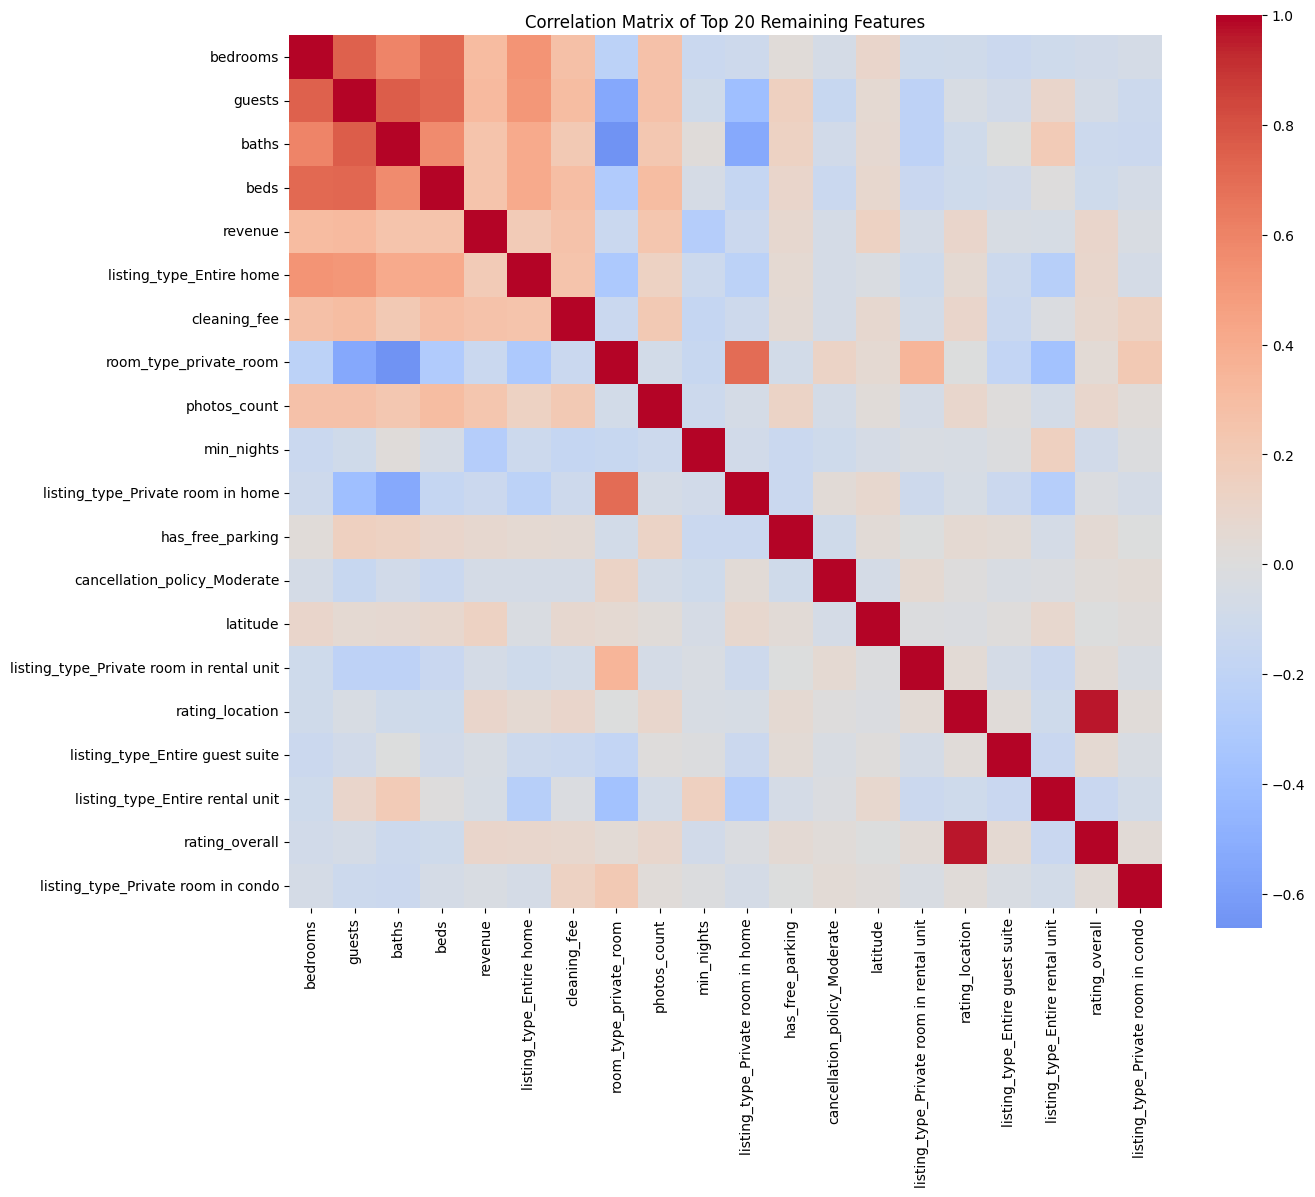

In [4]:
# Correlation matrix for top 20 remaining features
numeric_df = new_df.select_dtypes(include="number").copy()
corr_with_target = numeric_df.corr()["rate_avg"].abs().sort_values(ascending=False)
top_20_features = corr_with_target.drop("rate_avg").head(20).index.tolist()

print("Top 20 remaining features by |correlation| with rate_avg:")
print(top_20_features)

top_corr_matrix = numeric_df[top_20_features].corr()
plt.figure(figsize=(14, 12))
sns.heatmap(top_corr_matrix, cmap="coolwarm", center=0, square=True, annot=False)
plt.title("Correlation Matrix of Top 20 Remaining Features")
plt.tight_layout()
plt.show()